# **YOLO Instance Segmentation**

# 1.환경준비

## (1) 라이브러리 설치

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.7 MB/s eta 0:00:00


## (2) 라이브러리 불러오기

In [2]:
from ultralytics import settings, YOLO
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Video
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## (3) YOLO 설정

* 파일 경로 설정

In [3]:
# 현재 세팅을 확인해 봅시다.
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/datasets',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': '569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

In [4]:
# 콜랩 파일 탭에 보이는 경로('/content/')로 변경해 봅시다.
settings['datasets_dir'] = '/content/'
settings.update()
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': '569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

# 2.모델 사용

## (1) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [5]:
model = YOLO(model='yolo11s-seg.pt')

## (2) 모델 사용 : 이미지

![](https://file.fgtv.com/nanum_files/USERUPLOAD/N2_511/151021160645_01.jpg)


image 1/1 /content/151021160645_01.jpg: 448x640 3 persons, 1646.1ms
Speed: 25.7ms preprocess, 1646.1ms inference, 65.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/predict


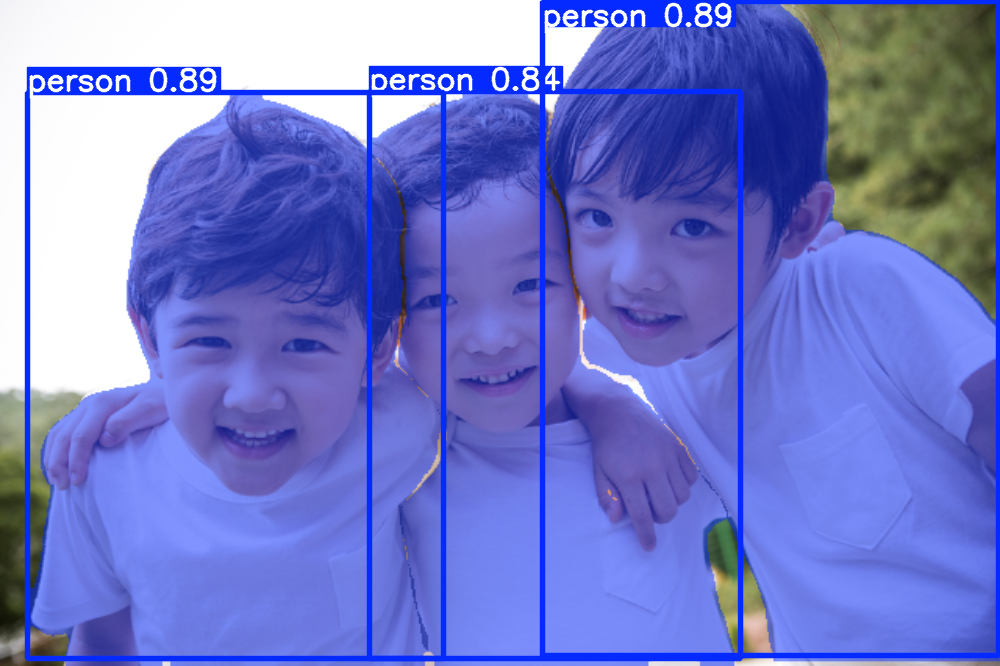

In [6]:
image_path = 'https://file.fgtv.com/nanum_files/USERUPLOAD/N2_511/151021160645_01.jpg'
results = model.predict(image_path, save=True)
results[0].show()  # 탐지된 객체 출력

In [7]:
r = results[0]
print(type(r.masks), None if r.masks is None else r.masks.data.shape)
# 예: (N, H, W) 형태면 N개의 개별 인스턴스 마스크가 나온 것
# 개수 확인
print("num instances:", 0 if r.masks is None else r.masks.data.shape[0])

<class 'ultralytics.engine.results.Masks'> torch.Size([3, 448, 640])
num instances: 3


## (3) 세그멘테이션 결과 열어보기

In [8]:
print(type(results))
print(len(results))

<class 'list'>
1


In [9]:
type(results[0])

ultralytics.engine.results.Results

In [10]:
r.boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0.])
conf: tensor([0.8933, 0.8850, 0.8381])
data: tensor([[2.7489e+01, 9.2742e+01, 4.4358e+02, 6.5897e+02, 8.9333e-01, 0.0000e+00],
        [5.4244e+02, 1.0002e+00, 9.9885e+02, 6.5564e+02, 8.8504e-01, 0.0000e+00],
        [3.6954e+02, 9.1345e+01, 7.4031e+02, 6.5827e+02, 8.3813e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (666, 1000)
shape: torch.Size([3, 6])
xywh: tensor([[235.5330, 375.8566, 416.0870, 566.2283],
        [770.6432, 328.3177, 456.4120, 654.6351],
        [554.9252, 374.8082, 370.7743, 566.9259]])
xywhn: tensor([[0.2355, 0.5643, 0.4161, 0.8502],
        [0.7706, 0.4930, 0.4564, 0.9829],
        [0.5549, 0.5628, 0.3708, 0.8512]])
xyxy: tensor([[ 27.4895,  92.7424, 443.5764, 658.9708],
        [542.4372,   1.0002, 998.8492, 655.6353],
        [369.5381,  91.3452, 740.3124, 658.2711]])
xyxyn: tensor([[0.0275, 0.1393, 0.4436, 0.9894],
        [0.5424, 0.0015, 0.9988, 0.9844],
        [0

In [11]:
for box in r.boxes:
    x_min, y_min, x_max, y_max = box.xyxy[0]  # 좌표
    conf = box.conf[0]
    cn = r.names[int(box.cls[0])]  # 클래스 이름
    print(f"좌표: {x_min}, {y_min}, {x_max}, {y_max} | conf. : {conf} | class : {cn}")

좌표: 27.489471435546875, 92.74244689941406, 443.5764465332031, 658.9707641601562 | conf. : 0.8933315873146057 | class : person
좌표: 542.4371948242188, 1.0001659393310547, 998.8492431640625, 655.63525390625 | conf. : 0.8850424885749817 | class : person
좌표: 369.5380859375, 91.34521484375, 740.3123779296875, 658.2711181640625 | conf. : 0.8381327986717224 | class : person


* masks
    * 객체별 마스크 정보 (픽셀 단위)를 담고 있는 객체

In [12]:
results[0].masks

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
orig_shape: (666, 1000)
shape: torch.Size([3, 448, 640])
xy: [array([[     229.69,      92.375],
       [     229.69,      98.625],
       [     226.5

| 속성 | 설명 |
|----|----|
|masks.data | (num_instances, H, W) 형태의 마스크 텐서 (0~1 값)|
|masks.xy | 각 인스턴스의 마스크 외곽선을 polygon으로 표현한 좌표 리스트|
|masks.shape | 마스크 텐서의 크기 (인스턴스 개수, 높이, 너비)|
|masks.bool() | True/False 형태로 변환한 binary mask|


In [13]:
# 마스크 정보
masks = r.masks

print(masks.data.shape)  # 예: torch.Size([3, 448, 640]) → 3개의 인스턴스
print(masks.data[0])     # 첫 번째 객체의 마스크 (0~1 값의 텐서)

torch.Size([3, 448, 640])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


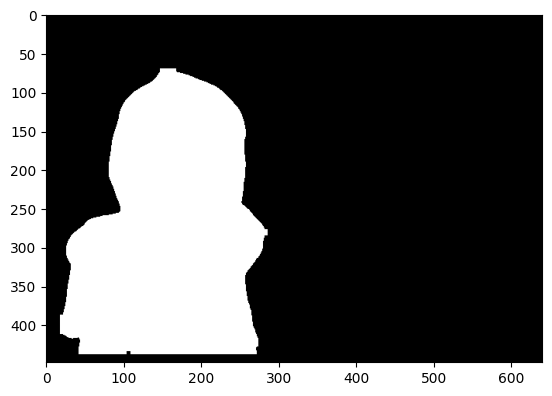

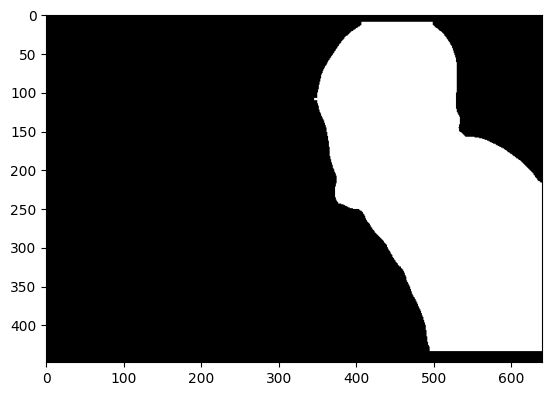

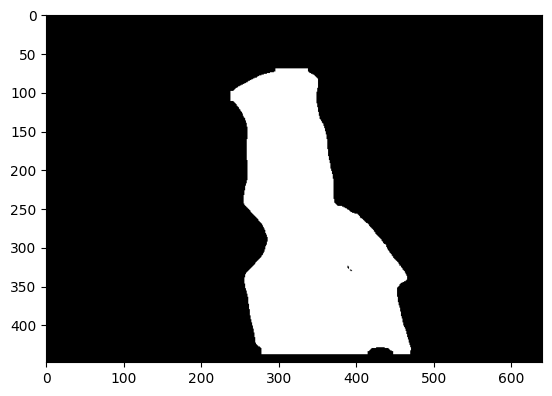

In [14]:
masks = r.masks

for i in range(3):
    mask = masks.data[i].numpy()
    plt.imshow(mask, cmap='gray')
    plt.show()

## (4) 실습
* 다양한 사진을 찾아서 세그멘테이션 해 봅시다.


image 1/1 /content/2018011700908_0.jpg: 320x640 5 cats, 5 dogs, 1881.4ms
Speed: 9.3ms preprocess, 1881.4ms inference, 93.5ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/segment/predict


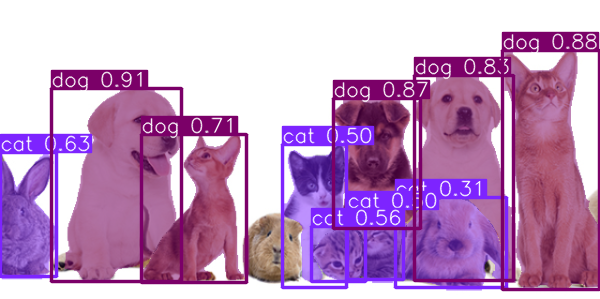

In [15]:
image_path = 'https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg'
results = model.predict(image_path, save=True)
results[0].show()  # 탐지된 객체 출력

## (5) 모델사용 : 동영상

* sample.mp4 파일을 업로드 합니다.

In [16]:
# colab 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving sample.mp4 to sample.mp4


* 동영상  실행

In [17]:
# 동영상  실행 및 결과 저장
results = model.predict("sample.mp4", save=True)  # 결과 자동 저장


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/210) /content/sample.mp4: 416x640 2 cats, 1 dog, 532.1ms
video 1/1 (frame 2/210) /content/sample.mp4: 416x640 2 cats, 1 dog, 517.8ms
video 1/1 (frame 3/210) /content/sample.mp4: 416x640 1 cat, 1 dog, 458.2ms
video 1/1 (frame 4/210) /content/sample.mp4: 416x640 1 cat, 1 dog, 557.1ms
video 1/1 (frame 5/210) /content/sample.mp4: 416x640 1 cat, 1 dog, 486.8ms
video 1/1 (frame 6/210) /content/sample.mp4: 416x640 2 cats, 1 dog, 476.4ms
vid

* 콜랩에서 영상 play를 위한 세팅

In [18]:
# 영상 코덱 설치
!apt-get install -y ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [19]:
# AVI to MP4로 변환 (YOLO 탐지 결과 파일명에 맞게 수정)
input_video_path = "runs/segment/predict/sample.avi"  # YOLO 탐지 결과 파일명
output_video_path = "runs/segment/predict/video_converted.mp4"

# FFmpeg를 사용하여 변환 (코덱: libx264)
!ffmpeg -i {input_video_path} -vcodec libx264 {output_video_path}

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

* 영상 paly

In [20]:
# YOLO 탐지 결과 동영상 재생
Video("runs/segment/predict/video_converted.mp4", embed=True)